# Modelling and Predicting Photovoltaic Power Output from Environmental Conditions

## Research Question

**How accurately can photovoltaic power output be predicted from environmental conditions, and how does a physics-based model compare with data-driven approaches?**

This project investigates photovoltaic (PV) power generation using measured environmental and electrical data from the PVDAQ dataset. The analysis combines three approaches:

1. **An empirical linear model** based on POA irradiance.
2. **A physics-informed model** incorporating the temperature dependence of PV efficiency.
3. **A Random Forest model** using environmental measurements as data-driven predictors.

The models are evaluated on temporally separated test data using mean absolute error (MAE), root mean squared error (RMSE), and the coefficient of determination (\(R^2\)). Energy yield is also estimated through numerical integration over valid measurement intervals.


## 1. Project Overview

Photovoltaic power output varies primarily with the solar irradiance incident on the PV system, while module temperature and other environmental conditions can also affect conversion efficiency.

The aim of this project is not simply to maximise predictive accuracy, but to compare different modelling approaches and investigate what information is actually required to predict PV output.

The analysis therefore progresses from a simple empirical relationship to a physics-informed model and finally to a nonlinear machine-learning model.

### Analysis workflow

**Data → Exploration → Physical modelling → Data-driven modelling → Evaluation → Energy analysis**

The project uses measured data rather than simulated PV output, allowing the models to be evaluated against real system measurements.

## 2. Dataset

### 2.1 PVDAQ

The data are obtained from the **Photovoltaic Data Acquisition (PVDAQ)** dataset provided through the Open Energy Information (OpenEI) platform.

The selected system is:

- **System:** 1433 — NREL RSF1
- **Location:** Golden, Colorado, USA
- **System type:** Rooftop, fixed
- **DC capacity:** 449.28 kW

The downloaded data consist of time-series measurements partitioned by system, year, month, and day.

### 2.2 Selected variables

Four measurements are used in the modelling analysis:

| Variable | PVDAQ metric | Units | Role |
|---|---:|---|---|
| POA irradiance | 5061 | W/m² | Predictor |
| Ambient temperature | 5062 | °C | Predictor |
| Module temperature | 5063 | °C | Predictor |
| AC power | 5069 | kW* | Target |

The PVDAQ metadata specify a calculation scale of 1000 for metric 5069. The stored values are therefore represented in kW for the modelling analysis after accounting for this scaling.

The analysis focuses on January 2018 data available in the downloaded files. Fourteen days of January data were used in the final analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

In [2]:
files_list = sorted(Path("/content").glob("*.parquet"))

print(f"Found {len(files_list)} parquet files")

jan = pd.concat(
    [pd.read_parquet(f) for f in files_list],
    ignore_index=True
)

jan["measured_on"] = pd.to_datetime(jan["measured_on"])

print("Shape:", jan.shape)
print("Date range:")
print(jan["measured_on"].min(), "to", jan["measured_on"].max())

Found 15 parquet files
Shape: (8594, 17)
Date range:
2018-01-01 00:00:00 to 2018-01-14 21:30:00


In [3]:
# Metrics used in the analysis
# 5061 = POA irradiance
# 5062 = ambient temperature
# 5063 = module temperature
# 5069 = AC power

core = jan[
    jan["metric_id"].isin([5061, 5062, 5063, 5069])
].copy()

data = (
    core
    .pivot_table(
        index="measured_on",
        columns="metric_id",
        values="value",
        aggfunc="mean"
    )
    .reset_index()
)

data.columns.name = None

data = data.rename(columns={
    5061: "poa_irradiance_W_m2",
    5062: "ambient_temp_C",
    5063: "module_temp_C",
    5069: "ac_power_kW"
})

data = (
    data
    .sort_values("measured_on")
    .reset_index(drop=True)
)

print(data.shape)
display(data.head())

(1335, 5)


,measured_on,poa_irradiance_W_m2,ambient_temp_C,module_temp_C,ac_power_kW
0,2018-01-01 00:00:00,-0.065866,-11.501200,-11.697533,NaN
1,2018-01-01 00:15:00,-0.076000,-11.342533,-11.544800,NaN
2,2018-01-01 00:30:00,-0.076000,-11.345933,-11.400933,NaN
3,2018-01-01 00:45:00,-0.070933,-11.373666,-11.395266,NaN
4,2018-01-01 01:00:00,-0.076000,-11.408066,-11.496600,NaN


In [4]:
print("Missing values:")
display(data.isna().sum())

print("\nDate range:")
print(data["measured_on"].min())
print(data["measured_on"].max())

print("\nObservations:")
print(len(data))

Missing values:


,0
measured_on,0
poa_irradiance_W_m2,0
ambient_temp_C,0
module_temp_C,0
ac_power_kW,673



Date range:
2018-01-01 00:00:00
2018-01-14 21:30:00

Observations:
1335


## 3. Data Preparation

The downloaded PVDAQ files contain measurements for multiple sensor metrics in a long-format time series. The relevant metrics are extracted and combined by timestamp to create a modelling dataset.

The AC power measurement is not available at every timestamp. These missing values are retained during the initial preparation rather than being interpreted as zero power. A missing measurement does not necessarily indicate zero PV generation.

For the supervised modelling analysis, observations must contain a measured AC power value and daytime irradiance above the selected threshold.

In [5]:
print("Total rows:", len(data))

print("\nAC power available:")
print(data["ac_power_kW"].notna().sum())

print("\nAC power missing:")
print(data["ac_power_kW"].isna().sum())

Total rows: 1335

AC power available:
662

AC power missing:
673


In [6]:
print("Missing values:")
display(data.isna().sum())

print("\nDate range:")
print(data["measured_on"].min())
print(data["measured_on"].max())

print("\nObservations:")
print(len(data))

Missing values:


,0
measured_on,0
poa_irradiance_W_m2,0
ambient_temp_C,0
module_temp_C,0
ac_power_kW,673



Date range:
2018-01-01 00:00:00
2018-01-14 21:30:00

Observations:
1335


### 3.1 Defining the Modelling Dataset

For the modelling analysis, observations are retained when AC power has been measured and POA irradiance is greater than 20 W/m².

The irradiance threshold removes near-night-time observations where the irradiance measurement is close to zero. Missing AC power measurements are not treated as zero generation.

This filtering produces the dataset used for model fitting and evaluation.

In [7]:
model_data = data[
    data["ac_power_kW"].notna() &
    (data["poa_irradiance_W_m2"] > 20)
].copy()

model_data = (
    model_data
    .sort_values("measured_on")
    .reset_index(drop=True)
)

print("Modelling observations:", len(model_data))

display(
    model_data[
        [
            "measured_on",
            "poa_irradiance_W_m2",
            "module_temp_C",
            "ambient_temp_C",
            "ac_power_kW"
        ]
    ].head()
)

Modelling observations: 374


,measured_on,poa_irradiance_W_m2,module_temp_C,ambient_temp_C,ac_power_kW
0,2018-01-01 08:30:00,93.516133,-8.810533,-8.149866,14.700
1,2018-01-01 08:45:00,121.205600,-8.108733,-7.621800,29.850
2,2018-01-01 09:00:00,118.866000,-8.308400,-8.201600,21.075
3,2018-01-01 09:15:00,167.211000,-7.582466,-7.632600,42.150
4,2018-01-01 09:30:00,133.286000,-7.078000,-7.432000,24.700


## 4. Exploratory Analysis

Before fitting the predictive models, the relationships between photovoltaic power output and the available environmental measurements are examined.

The analysis first considers the relationship between AC power and POA irradiance, followed by the relationship with module temperature. These comparisons provide an initial indication of which environmental variables contain useful predictive information.

## 5. Train/Test Methodology

To evaluate how well the models generalise to unseen data, the observations are divided chronologically rather than randomly.

The first ten days of the available modelling data are used for training, while the final four days are reserved as an independent test set.

This chronological split is appropriate for time-series data because it prevents measurements from later dates from being used to train a model that is subsequently evaluated on earlier or otherwise overlapping observations.

### Dataset split

| Dataset | Dates | Observations |
|---|---|---:|
| Training | 1–10 January 2018 | 263 |
| Test | 11–14 January 2018 | 111 |

The test set is kept separate from model fitting and is used only for the final performance evaluation.

In [8]:
model_data["date"] = model_data["measured_on"].dt.date

dates = sorted(model_data["date"].unique())

train_dates = dates[:10]
test_dates = dates[10:]

train_data = model_data[
    model_data["date"].isin(train_dates)
].copy()

test_data = model_data[
    model_data["date"].isin(test_dates)
].copy()

print("Training dates:")
print(train_dates)

print("\nTest dates:")
print(test_dates)

print("\nTraining observations:", len(train_data))
print("Test observations:", len(test_data))

Training dates:
[datetime.date(2018, 1, 1), datetime.date(2018, 1, 2), datetime.date(2018, 1, 3), datetime.date(2018, 1, 4), datetime.date(2018, 1, 5), datetime.date(2018, 1, 6), datetime.date(2018, 1, 7), datetime.date(2018, 1, 8), datetime.date(2018, 1, 9), datetime.date(2018, 1, 10)]

Test dates:
[datetime.date(2018, 1, 11), datetime.date(2018, 1, 12), datetime.date(2018, 1, 13), datetime.date(2018, 1, 14)]

Training observations: 263
Test observations: 111


### 5.1 Training-Only Outlier Screening

A residual-based screening procedure is applied to the training data before the final models are fitted.

The initial irradiance-only linear model is fitted to the training observations, and observations whose absolute residual exceeds **1.5 standard deviations** of the training residual distribution are flagged.

The 1.5-standard-deviation threshold is used here as a defined experimental screening criterion. It is not assumed to represent a universal definition of an outlier.

Importantly, this screening is performed **using the training data only**. The test observations are not removed or screened based on their prediction errors, preserving the independence of the final evaluation.

In [9]:
from sklearn.linear_model import LinearRegression

# Fit baseline model on the training data
X_train = train_data[["poa_irradiance_W_m2"]]
y_train = train_data["ac_power_kW"]

baseline_train = LinearRegression()
baseline_train.fit(X_train, y_train)

# Predictions and residuals on training data
train_data["baseline_pred_kW"] = baseline_train.predict(X_train)
train_data["baseline_residual_kW"] = (
    train_data["ac_power_kW"] - train_data["baseline_pred_kW"]
)

# 1.5 standard deviation screening rule
residual_sd = train_data["baseline_residual_kW"].std()
threshold = 1.5 * residual_sd

train_data["outlier"] = (
    train_data["baseline_residual_kW"].abs() > threshold
)

# Keep non-outliers for model fitting
train_clean = train_data[~train_data["outlier"]].copy()

print("Baseline slope:", baseline_train.coef_[0])
print("Baseline intercept:", baseline_train.intercept_)
print("Residual standard deviation:", residual_sd)
print("1.5 SD threshold:", threshold)
print("Training observations:", len(train_data))
print("Flagged observations:", train_data["outlier"].sum())
print("Observations after screening:", len(train_clean))

Baseline slope: 0.19613273738983425
Baseline intercept: -4.763606501605288
Residual standard deviation: 7.886950940524239
1.5 SD threshold: 11.830426410786359
Training observations: 263
Flagged observations: 18
Observations after screening: 245


## 6. Model 1: Empirical Irradiance Model

The first model provides a simple empirical baseline for photovoltaic power prediction.

POA irradiance is expected to be the dominant environmental factor affecting PV power output. Therefore, AC power is initially modelled as a linear function of POA irradiance:

**P_AC = aG + b**

where:

- **P_AC** is AC power in kW
- **G** is POA irradiance in W/m²
- **a** is the fitted irradiance coefficient
- **b** is the fitted intercept

This model uses only irradiance and provides a simple reference against which the physics-informed and data-driven models can be compared.

The model is fitted using the screened training data and is then evaluated on the independent test set.

### 6.1 Fitting the Baseline Model

The initial training residuals were used to identify observations exceeding the predefined 1.5 standard deviation screening threshold.

The irradiance-only model is then refitted using the remaining training observations. This refitted model is used to generate predictions for the independent test period.

In [10]:
# Refit the baseline model after training-data screening

X_train_clean = train_clean[["poa_irradiance_W_m2"]]
y_train_clean = train_clean["ac_power_kW"]

baseline_model = LinearRegression()
baseline_model.fit(X_train_clean, y_train_clean)

print("Screened baseline model")
print("----------------------")
print("Slope:", baseline_model.coef_[0])
print("Intercept:", baseline_model.intercept_)

Screened baseline model
----------------------
Slope: 0.19044810497592166
Intercept: -3.818748998793133


## 7. Model 2: Physics-Informed Model

The second model incorporates a simplified physical description of photovoltaic efficiency.

PV output is approximately proportional to incident irradiance, while module efficiency generally decreases as module temperature increases. This is represented by:

**P = P0 + kG[1 - beta(T - T_ref)]**

where:

- **P** is AC power in kW
- **G** is POA irradiance in W/m²
- **T** is module temperature in °C
- **T_ref** is the reference temperature, taken as 25 °C
- **k** is an effective irradiance-to-power coefficient
- **beta** is the effective temperature coefficient
- **P0** is an empirical intercept

The model is fitted to the screened training data.

The fitted temperature coefficient should be interpreted as an effective coefficient for this dataset rather than as a manufacturer-specified PV module parameter.

### 7.1 Estimating the Model Parameters

The coefficients of the physics-informed model are estimated from the training data.

The fitted parameters describe the effective relationship between irradiance, module temperature, and measured AC power for the selected PV system.


In [11]:
# Physics-informed model
# P = P0 + kG[1 - beta(T - T_ref)]

T_ref = 25.0

physics_data = train_clean.copy()

physics_data["G"] = physics_data["poa_irradiance_W_m2"]
physics_data["T_delta"] = physics_data["module_temp_C"] - T_ref
physics_data["G_T"] = (
    physics_data["G"] * physics_data["T_delta"]
)

X_physics_train = physics_data[["G", "G_T"]]
y_physics_train = physics_data["ac_power_kW"]

physics_model = LinearRegression()
physics_model.fit(X_physics_train, y_physics_train)

P0 = physics_model.intercept_
k = physics_model.coef_[0]
temperature_term = physics_model.coef_[1]

beta = -temperature_term / k

print("Physics-informed model")
print("---------------------")
print("P0:", P0)
print("k:", k)
print("Temperature term:", temperature_term)
print("Estimated beta:", beta, "per °C")

Physics-informed model
---------------------
P0: -4.091059993206052
k: 0.1809212952255549
Temperature term: -0.0007892939660644846
Estimated beta: 0.004362637162642852 per °C


In [12]:
# Make predictions on the untouched test data

test_results = test_data.copy()

# -----------------------------
# 1. Linear irradiance model
# -----------------------------
test_results["baseline_prediction_kW"] = baseline_model.predict(
    test_results[["poa_irradiance_W_m2"]]
)

# -----------------------------
# 2. Physics-informed model
# -----------------------------
test_results["G"] = test_results["poa_irradiance_W_m2"]

test_results["G_T"] = (
    test_results["poa_irradiance_W_m2"]
    * (test_results["module_temp_C"] - T_ref)
)

test_results["physics_prediction_kW"] = physics_model.predict(
    test_results[["G", "G_T"]]
)

# -----------------------------
# 3. Residuals
# -----------------------------
test_results["baseline_residual_kW"] = (
    test_results["ac_power_kW"]
    - test_results["baseline_prediction_kW"]
)

test_results["physics_residual_kW"] = (
    test_results["ac_power_kW"]
    - test_results["physics_prediction_kW"]
)

print("Test observations:", len(test_results))

display(test_results[[
    "measured_on",
    "poa_irradiance_W_m2",
    "module_temp_C",
    "ac_power_kW",
    "baseline_prediction_kW",
    "physics_prediction_kW"
]].head(10))

Test observations: 111


,measured_on,poa_irradiance_W_m2,module_temp_C,ac_power_kW,baseline_prediction_kW,physics_prediction_kW
263,2018-01-11 07:30:00,50.191333,-2.463466,2.900000,5.740095,6.077606
264,2018-01-11 07:45:00,99.090533,-2.034933,12.500000,15.052855,15.950972
265,2018-01-11 08:00:00,143.788733,-1.370866,35.700000,23.565543,24.916255
266,2018-01-11 08:45:00,274.287000,1.663466,49.050000,48.418690,50.585497
267,2018-01-11 09:00:00,314.264933,2.970200,57.100000,56.032412,58.230594
268,2018-01-11 09:15:00,352.462600,4.011666,64.550000,63.307085,65.515813
269,2018-01-11 09:30:00,371.704000,4.520000,102.000000,66.971573,69.166608
270,2018-01-11 09:45:00,421.620666,5.557400,81.162500,76.478108,78.659257
271,2018-01-11 10:00:00,452.835200,7.209133,86.300000,82.422857,84.195284
272,2018-01-11 10:15:00,479.482000,7.895200,90.877777,87.497689,89.130795


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Actual values
y_test = test_results["ac_power_kW"]

# Baseline metrics
baseline_mae = mean_absolute_error(
    y_test,
    test_results["baseline_prediction_kW"]
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_results["baseline_prediction_kW"]
    )
)

baseline_r2 = r2_score(
    y_test,
    test_results["baseline_prediction_kW"]
)

# Physics-informed metrics
physics_mae = mean_absolute_error(
    y_test,
    test_results["physics_prediction_kW"]
)

physics_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_results["physics_prediction_kW"]
    )
)

physics_r2 = r2_score(
    y_test,
    test_results["physics_prediction_kW"]
)

# Display results
results = pd.DataFrame({
    "Model": [
        "Linear irradiance",
        "Physics-informed"
    ],
    "MAE_kW": [
        baseline_mae,
        physics_mae
    ],
    "RMSE_kW": [
        baseline_rmse,
        physics_rmse
    ],
    "R2": [
        baseline_r2,
        physics_r2
    ]
})

display(results)

,Model,MAE_kW,RMSE_kW,R2
0,Linear irradiance,6.832027,13.813397,0.883553
1,Physics-informed,6.613340,13.835448,0.883181


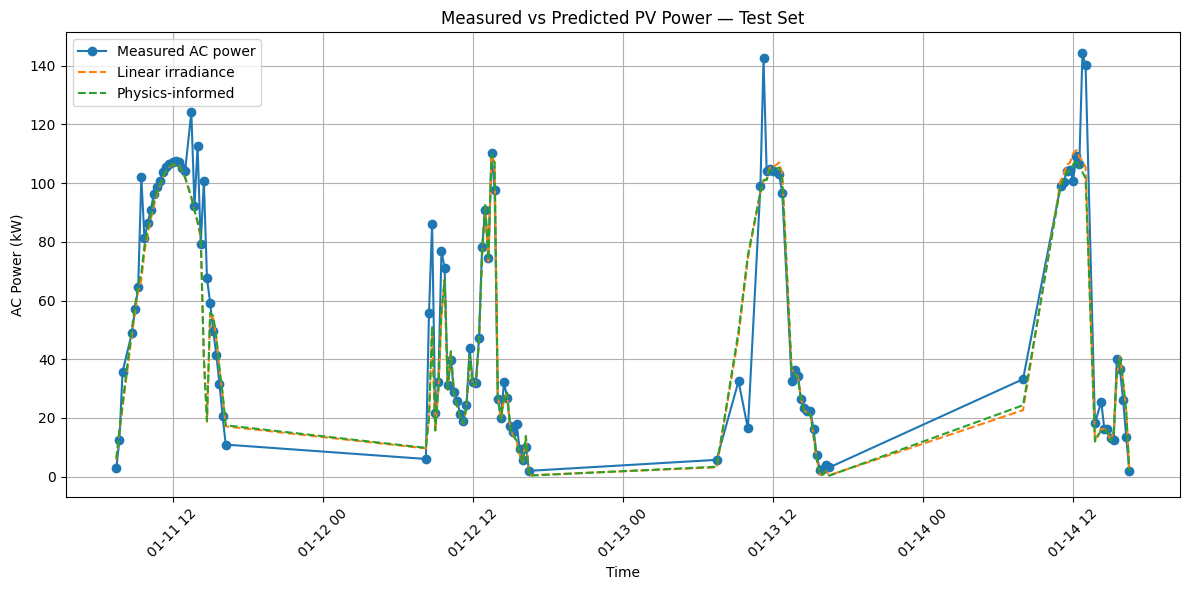

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    test_results["measured_on"],
    test_results["ac_power_kW"],
    marker="o",
    linestyle="-",
    label="Measured AC power"
)

plt.plot(
    test_results["measured_on"],
    test_results["baseline_prediction_kW"],
    linestyle="--",
    label="Linear irradiance"
)

plt.plot(
    test_results["measured_on"],
    test_results["physics_prediction_kW"],
    linestyle="--",
    label="Physics-informed"
)

plt.xlabel("Time")
plt.ylabel("AC Power (kW)")
plt.title("Measured vs Predicted PV Power — Test Set")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

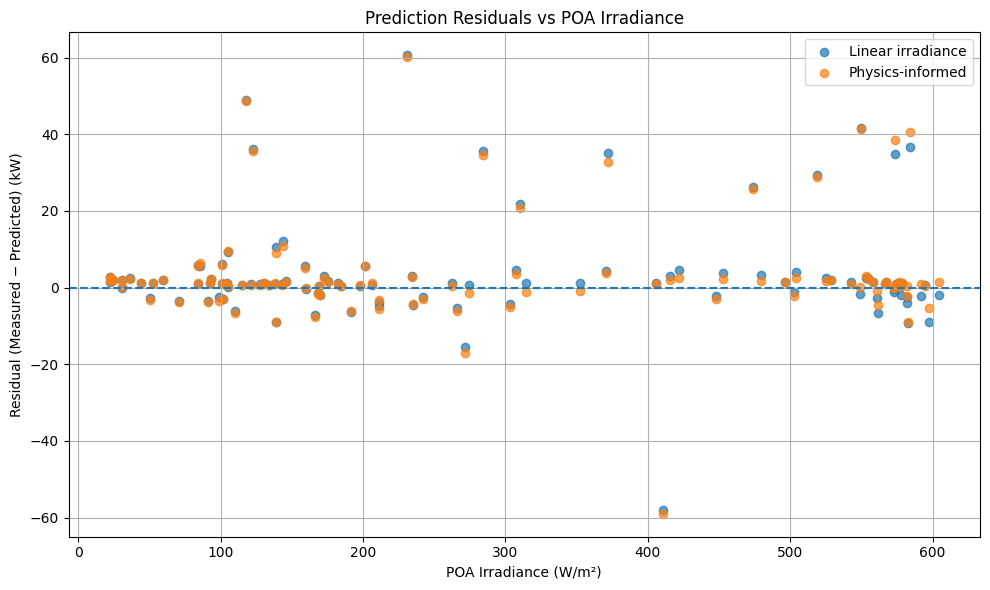

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    test_results["poa_irradiance_W_m2"],
    test_results["baseline_residual_kW"],
    alpha=0.7,
    label="Linear irradiance"
)

plt.scatter(
    test_results["poa_irradiance_W_m2"],
    test_results["physics_residual_kW"],
    alpha=0.7,
    label="Physics-informed"
)

plt.axhline(0, linestyle="--")

plt.xlabel("POA Irradiance (W/m²)")
plt.ylabel("Residual (Measured − Predicted) (kW)")
plt.title("Prediction Residuals vs POA Irradiance")
plt.legend()
plt.tight_layout()
plt.show()

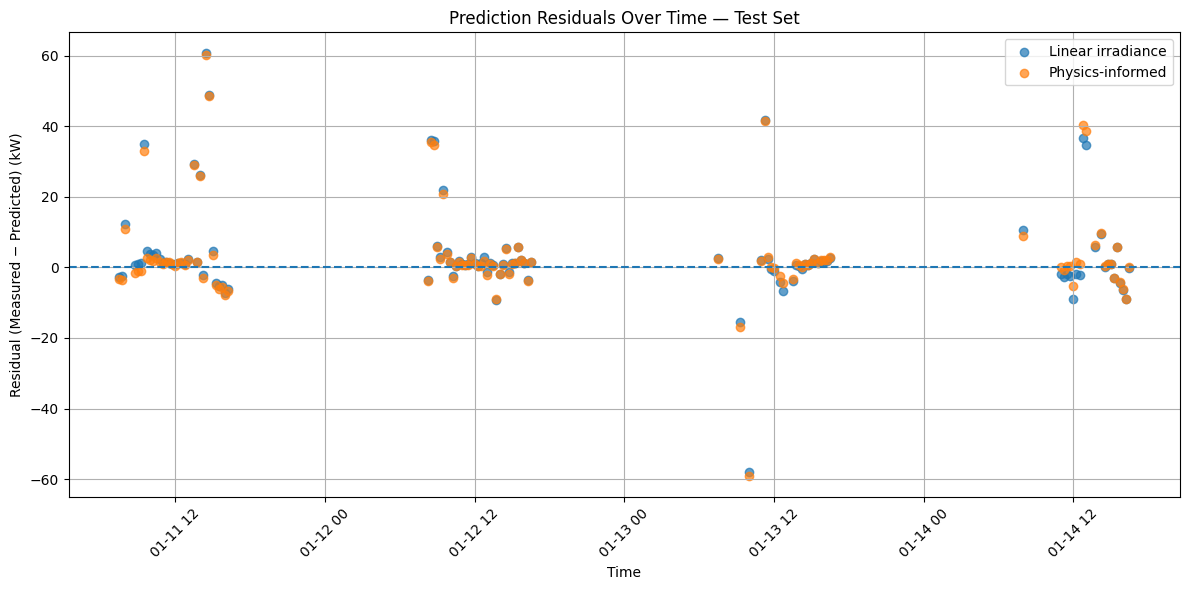

In [16]:
plt.figure(figsize=(12, 6))

plt.scatter(
    test_results["measured_on"],
    test_results["baseline_residual_kW"],
    label="Linear irradiance",
    alpha=0.7
)

plt.scatter(
    test_results["measured_on"],
    test_results["physics_residual_kW"],
    label="Physics-informed",
    alpha=0.7
)

plt.axhline(0, linestyle="--")

plt.xlabel("Time")
plt.ylabel("Residual (Measured − Predicted) (kW)")
plt.title("Prediction Residuals Over Time — Test Set")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Model 3: Random Forest

The third approach uses a Random Forest regression model to investigate whether a nonlinear, data-driven method can improve prediction accuracy.

The model uses three environmental measurements as predictors:

- **POA irradiance**
- **Module temperature**
- **Ambient temperature**

Unlike the physics-informed model, the Random Forest does not impose a predefined functional relationship between these variables and PV power. Instead, it learns relationships directly from the training data.

The Random Forest is configured with 300 trees and a minimum leaf size of 3 observations. A fixed random seed is used to make the results reproducible.

The model is trained using the screened training data and evaluated on the same independent test period used for the other models.

In [17]:
from sklearn.ensemble import RandomForestRegressor

features = [
    "poa_irradiance_W_m2",
    "module_temp_C",
    "ambient_temp_C"
]

# Training data
X_train_rf = train_clean[features]
y_train_rf = train_clean["ac_power_kW"]

# Test data
X_test_rf = test_data[features]
y_test_rf = test_data["ac_power_kW"]

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=3
)

rf_model.fit(X_train_rf, y_train_rf)

# Test predictions
rf_predictions = rf_model.predict(X_test_rf)

# Store predictions
test_results["rf_prediction_kW"] = rf_predictions

# Residuals
test_results["rf_residual_kW"] = (
    test_results["ac_power_kW"]
    - test_results["rf_prediction_kW"]
)

print("Random Forest trained.")
print("Training observations:", len(X_train_rf))
print("Test observations:", len(X_test_rf))

Random Forest trained.
Training observations: 245
Test observations: 111


In [18]:
# Random Forest test-set metrics

rf_mae = mean_absolute_error(
    y_test_rf,
    test_results["rf_prediction_kW"]
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test_rf,
        test_results["rf_prediction_kW"]
    )
)

rf_r2 = r2_score(
    y_test_rf,
    test_results["rf_prediction_kW"]
)

# Add Random Forest to the model comparison
results = pd.DataFrame({
    "Model": [
        "Linear irradiance",
        "Physics-informed",
        "Random Forest"
    ],
    "MAE_kW": [
        baseline_mae,
        physics_mae,
        rf_mae
    ],
    "RMSE_kW": [
        baseline_rmse,
        physics_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        physics_r2,
        rf_r2
    ]
})

display(results)

,Model,MAE_kW,RMSE_kW,R2
0,Linear irradiance,6.832027,13.813397,0.883553
1,Physics-informed,6.613340,13.835448,0.883181
2,Random Forest,6.827095,13.584204,0.887385


### 8.1 Random Forest Feature Importance

Feature importance is examined to determine which environmental variables contribute most to the Random Forest's predictions.

This provides an additional comparison with the physics-based analysis and helps assess whether temperature variables provide substantial predictive information beyond irradiance.

In [19]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
0,poa_irradiance_W_m2,0.996376
1,module_temp_C,0.002006
2,ambient_temp_C,0.001618


### 8.2 Random Forest Using Irradiance Only

A second Random Forest is trained using POA irradiance as the only predictor.

This provides a direct comparison with the three-feature Random Forest and tests whether adding module and ambient temperature provides a meaningful improvement in predictive performance.

In [20]:
# Random Forest using POA irradiance only

rf_irradiance = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=3
)

X_train_rf_g = train_clean[["poa_irradiance_W_m2"]]
X_test_rf_g = test_data[["poa_irradiance_W_m2"]]

rf_irradiance.fit(
    X_train_rf_g,
    y_train_rf
)

rf_g_pred = rf_irradiance.predict(X_test_rf_g)

# Metrics
rf_g_mae = mean_absolute_error(
    y_test_rf,
    rf_g_pred
)

rf_g_rmse = np.sqrt(
    mean_squared_error(
        y_test_rf,
        rf_g_pred
    )
)

rf_g_r2 = r2_score(
    y_test_rf,
    rf_g_pred
)

print("Random Forest — irradiance only")
print("--------------------------------")
print("MAE:", rf_g_mae)
print("RMSE:", rf_g_rmse)
print("R²:", rf_g_r2)

Random Forest — irradiance only
--------------------------------
MAE: 6.894067682846597
RMSE: 13.558014767411423
R²: 0.8878185678530934


## 9. Model Evaluation

The models are evaluated using the independent test dataset covering 11–14 January 2018.

Three standard regression metrics are used:

- **Mean Absolute Error (MAE):** the average magnitude of the prediction error.
- **Root Mean Squared Error (RMSE):** gives greater weight to larger prediction errors.
- **R²:** measures the proportion of variance in measured AC power explained by the model.

The test observations are not removed based on their prediction errors. This means that the reported metrics represent performance on the complete independent test set.

In [21]:
# Final point-prediction comparison

final_results = pd.DataFrame({
    "Model": [
        "Linear irradiance",
        "Physics-informed",
        "Random Forest",
        "Random Forest (irradiance only)"
    ],
    "Features": [
        "POA irradiance",
        "POA irradiance + module temperature",
        "POA irradiance + module temperature + ambient temperature",
        "POA irradiance"
    ],
    "MAE_kW": [
        baseline_mae,
        physics_mae,
        rf_mae,
        rf_g_mae
    ],
    "RMSE_kW": [
        baseline_rmse,
        physics_rmse,
        rf_rmse,
        rf_g_rmse
    ],
    "R2": [
        baseline_r2,
        physics_r2,
        rf_r2,
        rf_g_r2
    ]
})

display(final_results)

,Model,Features,MAE_kW,RMSE_kW,R2
0,Linear irradiance,POA irradiance,6.832027,13.813397,0.883553
1,Physics-informed,POA irradiance + module temperature,6.613340,13.835448,0.883181
2,Random Forest,POA irradiance + module temperature + ambient ...,6.827095,13.584204,0.887385
3,Random Forest (irradiance only),POA irradiance,6.894068,13.558015,0.887819


### 9.1 Point-Prediction Performance

The models produce very similar overall performance on the independent test set.

The physics-informed model gives the lowest MAE, while the Random Forest using irradiance alone gives the lowest RMSE and highest R². The differences between the models are relatively small, indicating that POA irradiance accounts for most of the predictable variation in AC power available from the selected environmental measurements.

### 9.1 Investigating the Largest Random Forest Residuals

Although the Random Forest provides a strong overall prediction of PV power, several observations have substantially larger residuals than the majority of the test set.

The observations with the largest absolute residuals are identified to determine whether these errors are isolated events or part of a broader systematic pattern.

These observations are **not removed from the primary test-set evaluation**. They are examined separately to understand the limitations of predicting AC power using the available environmental variables.

In [22]:
# Identify the largest absolute Random Forest residuals

test_results["abs_rf_residual_kW"] = (
    test_results["rf_residual_kW"].abs()
)

largest_errors = (
    test_results
    .sort_values("abs_rf_residual_kW", ascending=False)
    [[
        "measured_on",
        "poa_irradiance_W_m2",
        "module_temp_C",
        "ambient_temp_C",
        "ac_power_kW",
        "rf_prediction_kW",
        "rf_residual_kW",
        "abs_rf_residual_kW"
    ]]
    .head(15)
)

display(largest_errors)

,measured_on,poa_irradiance_W_m2,module_temp_C,ambient_temp_C,ac_power_kW,rf_prediction_kW,rf_residual_kW,abs_rf_residual_kW
288,2018-01-11 14:30:00,230.682400,8.780466,5.918600,100.700000,41.705845,58.994155,58.994155
332,2018-01-13 10:00:00,410.909066,9.056133,8.290066,16.400000,72.663225,-56.263225,56.263225
289,2018-01-11 14:45:00,118.052133,6.296600,4.635733,67.600000,19.311665,48.288335,48.288335
334,2018-01-13 11:15:00,549.418133,11.830200,9.341733,142.500000,101.637802,40.862198,40.862198
361,2018-01-14 12:45:00,584.426866,20.423266,16.621533,144.200000,103.602145,40.597855,40.597855
362,2018-01-14 13:00:00,573.649133,20.746000,16.645200,140.200000,102.276973,37.923027,37.923027
297,2018-01-12 08:30:00,122.761933,5.100133,6.048333,55.600000,19.859318,35.740682,35.740682
269,2018-01-11 09:30:00,371.704000,4.520000,3.662000,102.000000,70.382511,31.617489,31.617489
298,2018-01-12 08:45:00,284.378133,6.877200,7.254200,86.066666,57.037855,29.028811,29.028811
284,2018-01-11 13:30:00,518.564866,11.404866,6.906800,124.200000,96.559267,27.640733,27.640733


### 9.2 Examining the Largest Residuals in Context

The ten observations with the largest absolute Random Forest residuals are examined together with nearby measurements.

Looking at the observations immediately before and after each large error helps determine whether the deviations are isolated spikes or part of a short period of sustained disagreement between measured and predicted power.

This provides context for the residual analysis without removing these observations from the primary test-set evaluation.

In [23]:
# Show observations around each of the 10 largest RF errors

largest_error_times = (
    test_results
    .sort_values("abs_rf_residual_kW", ascending=False)
    .head(10)["measured_on"]
    .tolist()
)

for t in largest_error_times:
    window = test_results[
        (test_results["measured_on"] >= t - pd.Timedelta(minutes=30)) &
        (test_results["measured_on"] <= t + pd.Timedelta(minutes=30))
    ].copy()

    print("\n" + "=" * 80)
    print("Largest-error timestamp:", t)

    display(window[[
        "measured_on",
        "poa_irradiance_W_m2",
        "module_temp_C",
        "ac_power_kW",
        "rf_prediction_kW",
        "rf_residual_kW"
    ]])


Largest-error timestamp: 2018-01-11 14:30:00


,measured_on,poa_irradiance_W_m2,module_temp_C,ac_power_kW,rf_prediction_kW,rf_residual_kW
286,2018-01-11 14:00:00,473.780200,10.898600,112.7,90.528158,22.171842
287,2018-01-11 14:15:00,447.789600,10.154533,79.2,84.033765,-4.833765
288,2018-01-11 14:30:00,230.682400,8.780466,100.7,41.705845,58.994155
289,2018-01-11 14:45:00,118.052133,6.296600,67.6,19.311665,48.288335
290,2018-01-11 15:00:00,307.459600,7.422733,59.3,58.577351,0.722649



Largest-error timestamp: 2018-01-13 10:00:00


,measured_on,poa_irradiance_W_m2,module_temp_C,ac_power_kW,rf_prediction_kW,rf_residual_kW
332,2018-01-13 10:00:00,410.909066,9.056133,16.4,72.663225,-56.263225



Largest-error timestamp: 2018-01-11 14:45:00


...

,measured_on,poa_irradiance_W_m2,module_temp_C,ac_power_kW,rf_prediction_kW,rf_residual_kW
267,2018-01-11 09:00:00,314.264933,2.970200,57.1000,59.276796,-2.176796
268,2018-01-11 09:15:00,352.462600,4.011666,64.5500,64.457831,0.092169
269,2018-01-11 09:30:00,371.704000,4.520000,102.0000,70.382511,31.617489
270,2018-01-11 09:45:00,421.620666,5.557400,81.1625,75.808173,5.354327
271,2018-01-11 10:00:00,452.835200,7.209133,86.3000,84.416071,1.883929



Largest-error timestamp: 2018-01-12 08:45:00


,measured_on,poa_irradiance_W_m2,module_temp_C,ac_power_kW,rf_prediction_kW,rf_residual_kW
296,2018-01-12 08:15:00,70.490533,4.873933,6.000000,10.721810,-4.721810
297,2018-01-12 08:30:00,122.761933,5.100133,55.600000,19.859318,35.740682
298,2018-01-12 08:45:00,284.378133,6.877200,86.066666,57.037855,29.028811
299,2018-01-12 09:00:00,101.272600,6.946933,21.500000,13.146753,8.353247
300,2018-01-12 09:15:00,172.510933,6.592266,32.100000,26.738813,5.361187



Largest-error timestamp: 2018-01-11 13:30:00


,measured_on,poa_irradiance_W_m2,module_temp_C,ac_power_kW,rf_prediction_kW,rf_residual_kW
283,2018-01-11 13:00:00,554.275533,11.587800,104.2,103.643783,0.556217
284,2018-01-11 13:30:00,518.564866,11.404866,124.2,96.559267,27.640733
285,2018-01-11 13:45:00,496.287133,12.146533,92.2,91.614512,0.585488
286,2018-01-11 14:00:00,473.780200,10.898600,112.7,90.528158,22.171842


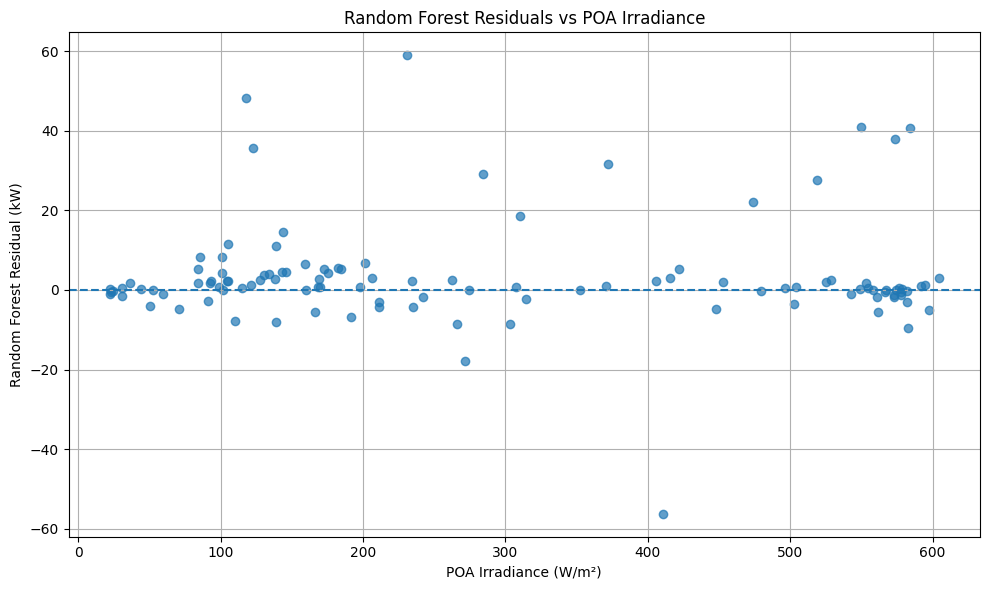

In [41]:
# Residuals vs POA irradiance

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    test_results["poa_irradiance_W_m2"],
    test_results["rf_residual_kW"],
    alpha=0.7
)

plt.axhline(0, linestyle="--")

plt.xlabel("POA Irradiance (W/m²)")
plt.ylabel("Random Forest Residual (kW)")
plt.title("Random Forest Residuals vs POA Irradiance")

plt.tight_layout()
plt.show()

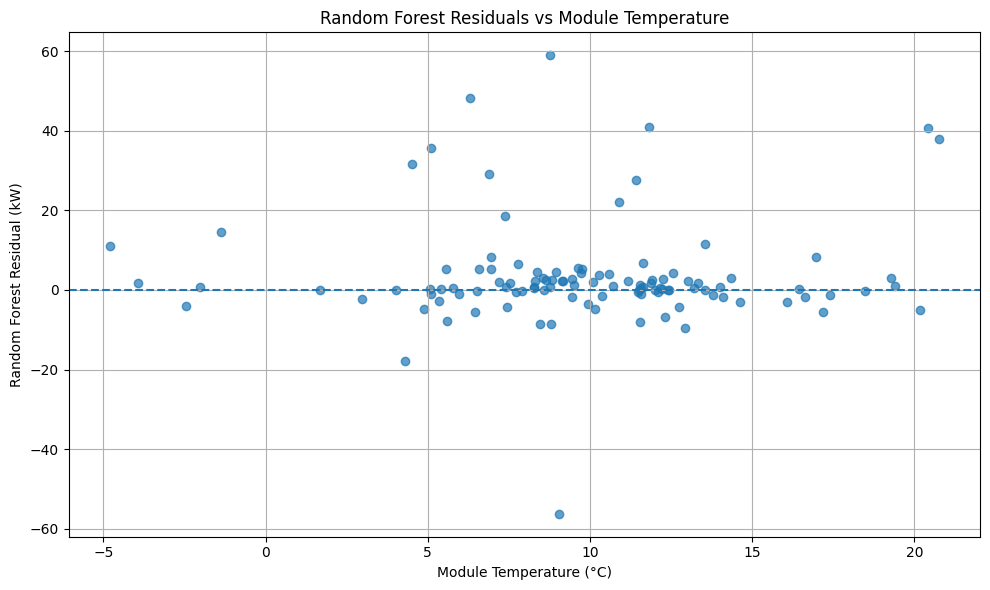

In [43]:
# Residuals vs module temperature

plt.figure(figsize=(10, 6))

plt.scatter(
    test_results["module_temp_C"],
    test_results["rf_residual_kW"],
    alpha=0.7
)

plt.axhline(0, linestyle="--")

plt.xlabel("Module Temperature (°C)")
plt.ylabel("Random Forest Residual (kW)")
plt.title("Random Forest Residuals vs Module Temperature")

plt.tight_layout()
plt.show()

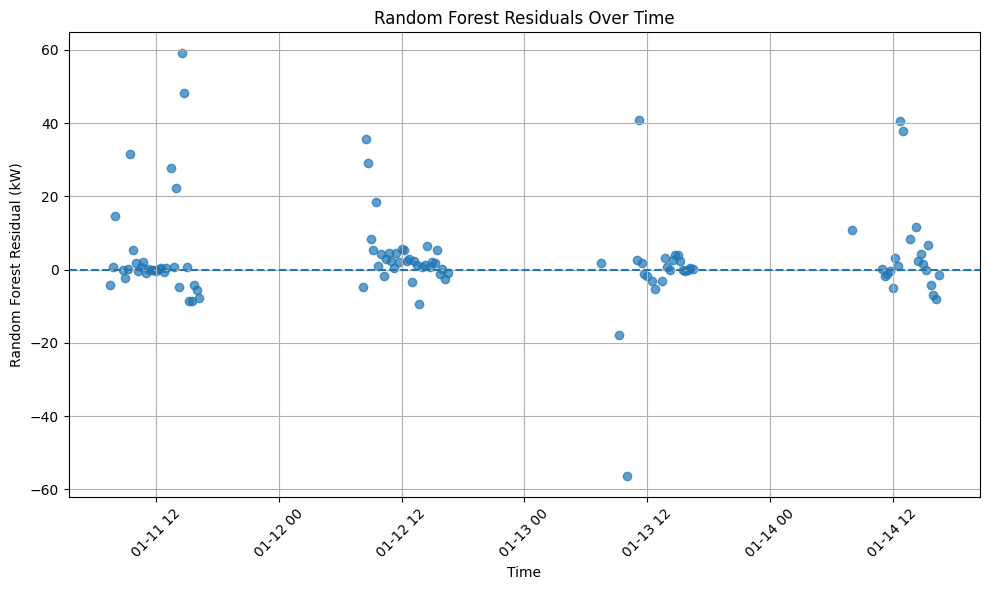

In [42]:
# Random Forest residuals over time

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    test_results["measured_on"],
    test_results["rf_residual_kW"],
    alpha=0.7
)

plt.axhline(0, linestyle="--")

plt.xlabel("Time")
plt.ylabel("Random Forest Residual (kW)")
plt.title("Random Forest Residuals Over Time")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 9.3 Residuals vs Module Temperature

The residuals are plotted against module temperature to investigate whether prediction errors show any systematic dependence on temperature.

If temperature is not adequately represented by the models, a clear trend in the residuals would be expected as module temperature changes.

The plot is used to assess whether the remaining prediction errors are systematically related to module temperature.

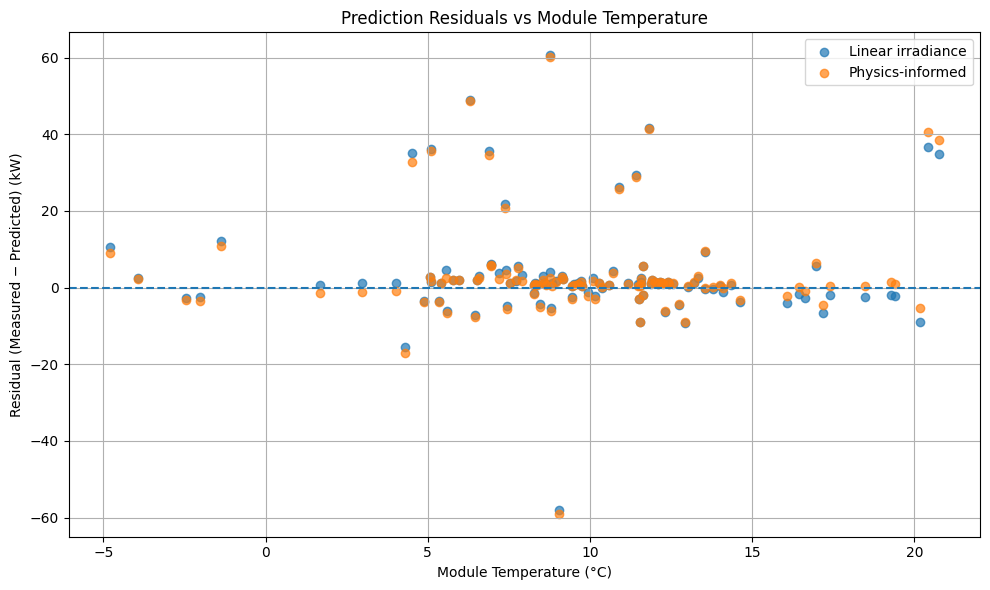

In [24]:
plt.figure(figsize=(10, 6))

plt.scatter(
    test_results["module_temp_C"],
    test_results["baseline_residual_kW"],
    alpha=0.7,
    label="Linear irradiance"
)

plt.scatter(
    test_results["module_temp_C"],
    test_results["physics_residual_kW"],
    alpha=0.7,
    label="Physics-informed"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Module Temperature (°C)")
plt.ylabel("Residual (Measured − Predicted) (kW)")
plt.title("Prediction Residuals vs Module Temperature")
plt.legend()
plt.tight_layout()
plt.show()

### 10.1 Preparing Data for Energy Estimation

To compare measured and predicted energy production, the power predictions are converted to energy using trapezoidal integration.

Only intervals of **30 minutes or less** are included, ensuring that energy is not estimated across larger gaps in the test-set measurements.

In [25]:
import pandas as pd
import numpy as np

energy_data = test_results[
    [
        "measured_on",
        "ac_power_kW",
        "baseline_prediction_kW",
        "physics_prediction_kW",
        "rf_prediction_kW"
    ]
].copy()

energy_data["measured_on"] = pd.to_datetime(
    energy_data["measured_on"]
)

energy_data = (
    energy_data
    .sort_values("measured_on")
    .reset_index(drop=True)
)

# Time between consecutive observations
energy_data["time_delta_h"] = (
    energy_data["measured_on"].diff().dt.total_seconds() / 3600
)

# Only integrate across reasonably continuous intervals
MAX_GAP_H = 0.5

energy_data["valid_interval"] = (
    (energy_data["time_delta_h"] > 0) &
    (energy_data["time_delta_h"] <= MAX_GAP_H)
)

# Trapezoidal integration
for power_col, energy_col in [
    ("ac_power_kW", "measured_energy_kWh"),
    ("baseline_prediction_kW", "baseline_energy_kWh"),
    ("physics_prediction_kW", "physics_energy_kWh"),
    ("rf_prediction_kW", "rf_energy_kWh")
]:

    energy_data[energy_col] = np.where(
        energy_data["valid_interval"],
        (
            energy_data[power_col]
            + energy_data[power_col].shift(1)
        ) / 2
        * energy_data["time_delta_h"],
        np.nan
    )

print("Valid intervals:", energy_data["valid_interval"].sum())
print("Total valid time (hours):",
      energy_data.loc[
          energy_data["valid_interval"],
          "time_delta_h"
      ].sum())

display(energy_data.head(10))

Valid intervals: 100
Total valid time (hours): 25.75


,measured_on,ac_power_kW,baseline_prediction_kW,physics_prediction_kW,rf_prediction_kW,time_delta_h,valid_interval,measured_energy_kWh,baseline_energy_kWh,physics_energy_kWh,rf_energy_kWh
0,2018-01-11 07:30:00,2.900000,5.740095,6.077606,7.032210,NaN,False,NaN,NaN,NaN,NaN
1,2018-01-11 07:45:00,12.500000,15.052855,15.950972,11.676055,0.25,True,1.925000,2.599119,2.753572,2.338533
2,2018-01-11 08:00:00,35.700000,23.565543,24.916255,21.063788,0.25,True,6.025000,4.827300,5.108403,4.092480
3,2018-01-11 08:45:00,49.050000,48.418690,50.585497,49.164637,0.75,False,NaN,NaN,NaN,NaN
4,2018-01-11 09:00:00,57.100000,56.032412,58.230594,59.276796,0.25,True,13.268750,13.056388,13.602011,13.555179
5,2018-01-11 09:15:00,64.550000,63.307085,65.515813,64.457831,0.25,True,15.206250,14.917437,15.468301,15.466828
6,2018-01-11 09:30:00,102.000000,66.971573,69.166608,70.382511,0.25,True,20.818750,16.284832,16.835303,16.855043
7,2018-01-11 09:45:00,81.162500,76.478108,78.659257,75.808173,0.25,True,22.895312,17.931210,18.478233,18.273836
8,2018-01-11 10:00:00,86.300000,82.422857,84.195284,84.416071,0.25,True,20.932812,19.862621,20.356818,20.028031
9,2018-01-11 10:15:00,90.877777,87.497689,89.130795,91.253540,0.25,True,22.147222,21.240068,21.665760,21.958701


### 10.2 Daily Energy Comparison

The integrated power values are aggregated by day to compare measured energy with the energy estimated by each model.

Daily energy errors are calculated as the difference between predicted and measured energy. The coverage percentage indicates the fraction of each 24-hour day represented by valid measurement intervals.

In [26]:
# Add date
energy_data["date"] = energy_data["measured_on"].dt.date

# Daily energy totals
daily_energy = (
    energy_data
    .groupby("date")
    .agg(
        measured_energy_kWh=("measured_energy_kWh", "sum"),
        baseline_energy_kWh=("baseline_energy_kWh", "sum"),
        physics_energy_kWh=("physics_energy_kWh", "sum"),
        rf_energy_kWh=("rf_energy_kWh", "sum"),
        valid_intervals=("valid_interval", "sum"),
        valid_time_h=(
            "time_delta_h",
            lambda x: x[
                energy_data.loc[x.index, "valid_interval"]
            ].sum()
        )
    )
    .reset_index()
)

# Energy errors
daily_energy["baseline_error_kWh"] = (
    daily_energy["baseline_energy_kWh"]
    - daily_energy["measured_energy_kWh"]
)

daily_energy["physics_error_kWh"] = (
    daily_energy["physics_energy_kWh"]
    - daily_energy["measured_energy_kWh"]
)

daily_energy["rf_error_kWh"] = (
    daily_energy["rf_energy_kWh"]
    - daily_energy["measured_energy_kWh"]
)

# Fraction of a 24-hour day represented by valid intervals
daily_energy["coverage_percent"] = (
    daily_energy["valid_time_h"] / 24 * 100
)

display(daily_energy)

,date,measured_energy_kWh,baseline_energy_kWh,physics_energy_kWh,rf_energy_kWh,valid_intervals,valid_time_h,baseline_error_kWh,physics_error_kWh,rf_error_kWh,coverage_percent
0,2018-01-11,644.928580,587.490411,593.674447,599.592200,31,8.00,-57.438169,-51.254134,-45.336381,33.333333
1,2018-01-12,331.360074,301.141177,303.787886,297.400676,33,8.25,-30.218896,-27.572188,-33.959398,34.375000
2,2018-01-13,243.752182,232.348404,230.327821,231.831514,18,4.75,-11.403778,-13.424360,-11.920668,19.791667
3,2018-01-14,280.443333,271.226475,264.604139,261.466127,18,4.75,-9.216858,-15.839194,-18.977206,19.791667


### 10.3 Overall Energy Comparison

The daily energy estimates are summed across all valid intervals in the test set to compare the total measured energy with the energy estimated by each model.

Absolute and relative energy errors are calculated with respect to the measured energy. These totals represent only the valid measurement intervals included in the integration, rather than the complete energy production over the test period.

In [27]:
# Overall energy totals across all valid intervals

total_measured = daily_energy["measured_energy_kWh"].sum()
total_baseline = daily_energy["baseline_energy_kWh"].sum()
total_physics = daily_energy["physics_energy_kWh"].sum()
total_rf = daily_energy["rf_energy_kWh"].sum()

energy_results = pd.DataFrame({
    "Model": [
        "Measured",
        "Linear irradiance",
        "Physics-informed",
        "Random Forest"
    ],
    "Energy_kWh": [
        total_measured,
        total_baseline,
        total_physics,
        total_rf
    ]
})

# Absolute and relative errors
energy_results["Error_kWh"] = (
    energy_results["Energy_kWh"] - total_measured
)

energy_results["Relative_error_percent"] = (
    energy_results["Error_kWh"]
    / total_measured
    * 100
)

# Measured energy has zero error by definition
energy_results.loc[
    energy_results["Model"] == "Measured",
    ["Error_kWh", "Relative_error_percent"]
] = 0

display(energy_results)

,Model,Energy_kWh,Error_kWh,Relative_error_percent
0,Measured,1500.484169,0.000000,0.000000
1,Linear irradiance,1392.206468,-108.277701,-7.216184
2,Physics-informed,1392.394293,-108.089876,-7.203667
3,Random Forest,1390.290516,-110.193653,-7.343873


### 10.4 Sensitivity to the Maximum Time Gap

The energy estimates depend on how large a gap between consecutive measurements is allowed during numerical integration.

To assess this sensitivity, the energy calculation is repeated using maximum allowed gaps of **15, 30, and 45 minutes**.

Comparing the resulting energy estimates and relative errors shows whether the conclusions are sensitive to the choice of integration interval.

In [28]:
# Sensitivity of energy results to the maximum allowed time gap

max_gaps = {
    "15 min": 0.25,
    "30 min": 0.50,
    "45 min": 0.75
}

sensitivity_results = []

for label, max_gap in max_gaps.items():

    temp = energy_data.copy()

    temp["valid"] = (
        (temp["time_delta_h"] > 0) &
        (temp["time_delta_h"] <= max_gap)
    )

    # Calculate energy for each model
    energies = {}

    for power_col, energy_name in [
        ("ac_power_kW", "measured"),
        ("baseline_prediction_kW", "baseline"),
        ("physics_prediction_kW", "physics"),
        ("rf_prediction_kW", "rf")
    ]:

        interval_energy = np.where(
            temp["valid"],
            (
                temp[power_col]
                + temp[power_col].shift(1)
            ) / 2
            * temp["time_delta_h"],
            np.nan
        )

        energies[energy_name] = np.nansum(interval_energy)

    measured = energies["measured"]

    sensitivity_results.append({
        "max_gap": label,
        "valid_intervals": int(temp["valid"].sum()),
        "valid_time_h": temp.loc[
            temp["valid"], "time_delta_h"
        ].sum(),
        "measured_energy_kWh": measured,
        "baseline_energy_kWh": energies["baseline"],
        "physics_energy_kWh": energies["physics"],
        "rf_energy_kWh": energies["rf"],
        "baseline_error_percent": (
            (energies["baseline"] - measured)
            / measured * 100
        ),
        "physics_error_percent": (
            (energies["physics"] - measured)
            / measured * 100
        ),
        "rf_error_percent": (
            (energies["rf"] - measured)
            / measured * 100
        )
    })

sensitivity_results = pd.DataFrame(sensitivity_results)

display(sensitivity_results)

,max_gap,valid_intervals,valid_time_h,measured_energy_kWh,baseline_energy_kWh,physics_energy_kWh,rf_energy_kWh,baseline_error_percent,physics_error_percent,rf_error_percent
0,15 min,97,24.25,1380.646669,1282.780888,1283.651707,1281.258637,-7.088402,-7.025328,-7.198658
1,30 min,100,25.75,1500.484169,1392.206468,1392.394293,1390.290516,-7.216184,-7.203667,-7.343873
2,45 min,104,28.75,1658.415419,1561.617596,1561.434814,1556.450687,-5.836766,-5.847787,-6.148323


In [29]:
# Save key results tables

final_results.to_csv(
    "model_comparison.csv",
    index=False
)

energy_results.to_csv(
    "energy_comparison.csv",
    index=False
)

sensitivity_results.to_csv(
    "energy_gap_sensitivity.csv",
    index=False
)

feature_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

print("Results tables saved successfully.")

Results tables saved successfully.


### 10.5 Measured and Predicted PV Power

The measured AC power is compared with the predictions from the linear irradiance, physics-informed, and Random Forest models across the test set.

This time-series comparison provides a visual assessment of how closely each model follows the observed PV power output and highlights periods where the models show larger deviations from the measurements.

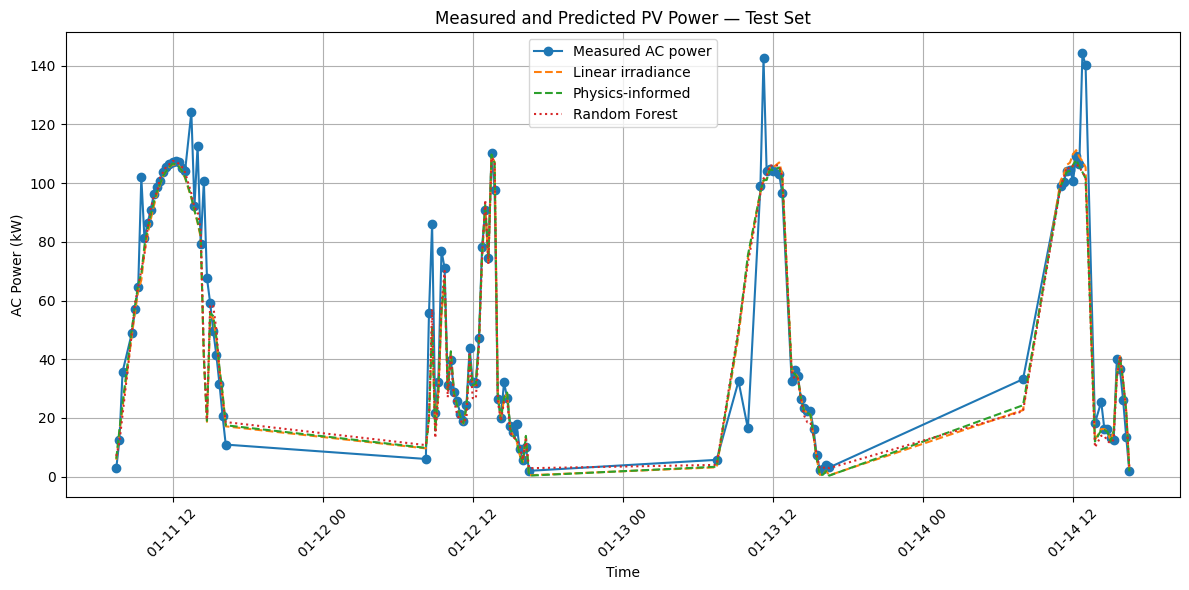

In [30]:
plt.figure(figsize=(12, 6))

plt.plot(
    test_results["measured_on"],
    test_results["ac_power_kW"],
    marker="o",
    linewidth=1.5,
    label="Measured AC power"
)

plt.plot(
    test_results["measured_on"],
    test_results["baseline_prediction_kW"],
    linewidth=1.5,
    linestyle="--",
    label="Linear irradiance"
)

plt.plot(
    test_results["measured_on"],
    test_results["physics_prediction_kW"],
    linewidth=1.5,
    linestyle="--",
    label="Physics-informed"
)

plt.plot(
    test_results["measured_on"],
    test_results["rf_prediction_kW"],
    linewidth=1.5,
    linestyle=":",
    label="Random Forest"
)

plt.xlabel("Time")
plt.ylabel("AC Power (kW)")
plt.title("Measured and Predicted PV Power — Test Set")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
plt.savefig(
    "measured_vs_predicted_test_set.png",
    dpi=300,
    bbox_inches="tight"
)

print("Figure saved.")

Figure saved.


<Figure size 1000x600 with 0 Axes>

### 10.6 Prediction Residuals vs POA Irradiance

The prediction residuals are plotted against POA irradiance to investigate whether model errors show any systematic dependence on irradiance.

A consistent trend or changing spread in the residuals could indicate that the models perform differently across different irradiance levels.

The comparison focuses on the linear irradiance and physics-informed models.

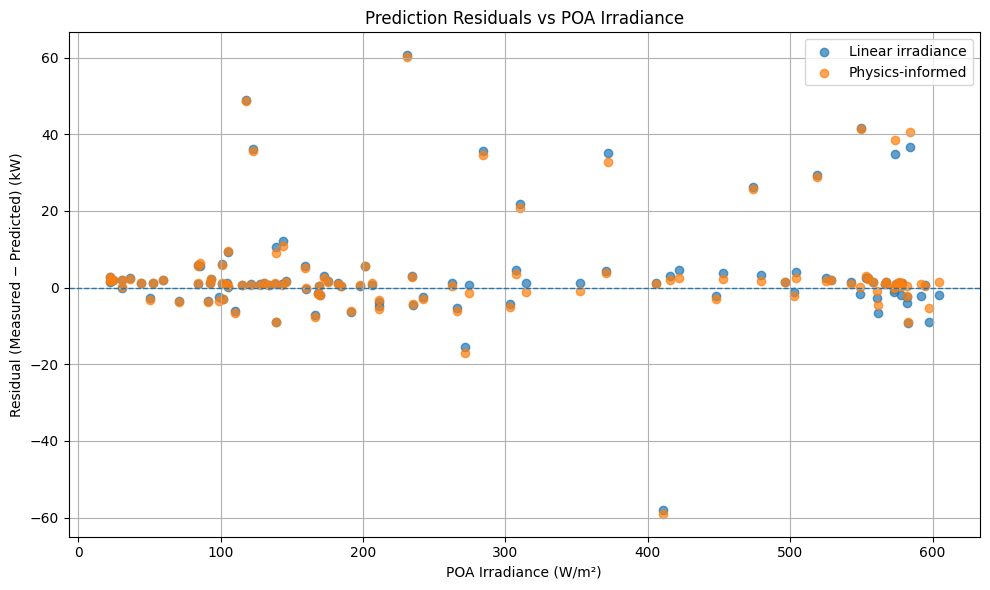

In [32]:
plt.figure(figsize=(10, 6))

plt.scatter(
    test_results["poa_irradiance_W_m2"],
    test_results["baseline_residual_kW"],
    alpha=0.7,
    label="Linear irradiance"
)

plt.scatter(
    test_results["poa_irradiance_W_m2"],
    test_results["physics_residual_kW"],
    alpha=0.7,
    label="Physics-informed"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("POA Irradiance (W/m²)")
plt.ylabel("Residual (Measured − Predicted) (kW)")
plt.title("Prediction Residuals vs POA Irradiance")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
plt.savefig(
    "residuals_vs_irradiance.png",
    dpi=300,
    bbox_inches="tight"
)

print("Figure saved.")

Figure saved.


<Figure size 1000x600 with 0 Axes>

### 10.7 Prediction Residuals Over Time

The prediction residuals for all three models are plotted over the test period to examine how the prediction errors vary with time.

Comparing the residuals across the models helps identify periods where their predictions diverge from the measured AC power and whether large errors occur as isolated events or persist over time.

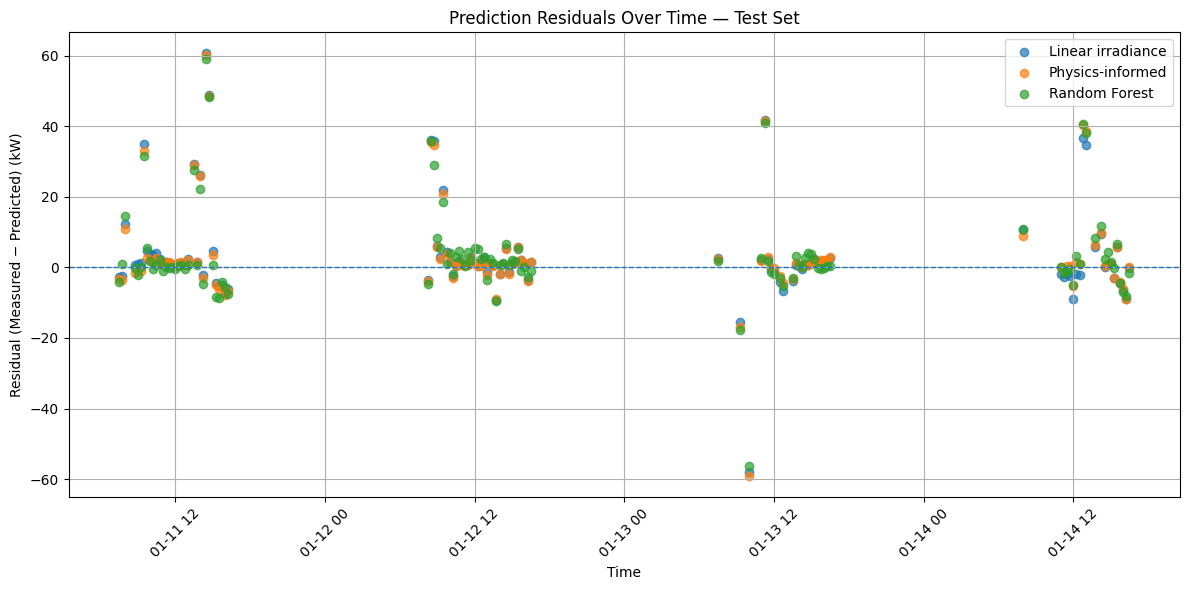

In [34]:
plt.figure(figsize=(12, 6))

plt.scatter(
    test_results["measured_on"],
    test_results["baseline_residual_kW"],
    alpha=0.7,
    label="Linear irradiance"
)

plt.scatter(
    test_results["measured_on"],
    test_results["physics_residual_kW"],
    alpha=0.7,
    label="Physics-informed"
)

plt.scatter(
    test_results["measured_on"],
    test_results["rf_residual_kW"],
    alpha=0.7,
    label="Random Forest"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Time")
plt.ylabel("Residual (Measured − Predicted) (kW)")
plt.title("Prediction Residuals Over Time — Test Set")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
plt.savefig(
    "residuals_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

print("Figure saved.")

Figure saved.


<Figure size 1000x600 with 0 Axes>

### 10.8 Random Forest Feature Importance

The feature importance scores from the Random Forest are visualised to assess the relative contribution of POA irradiance, module temperature, and ambient temperature to the model's predictions.

This provides an additional comparison with the physics-informed model by showing which environmental variables contribute most to the data-driven prediction.

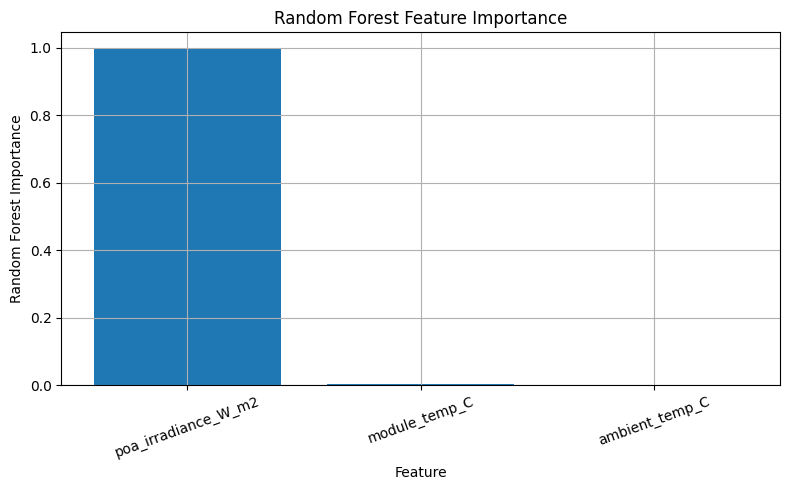

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Random Forest Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [37]:
plt.savefig(
    "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

print("Figure saved.")

Figure saved.


<Figure size 1000x600 with 0 Axes>

### 10.9 Measured vs Predicted Energy

The total energy represented by the valid measurement intervals is compared across the three models.

The measured energy is shown as a reference line, allowing the magnitude of the difference between the measured and predicted energy estimates to be assessed visually.

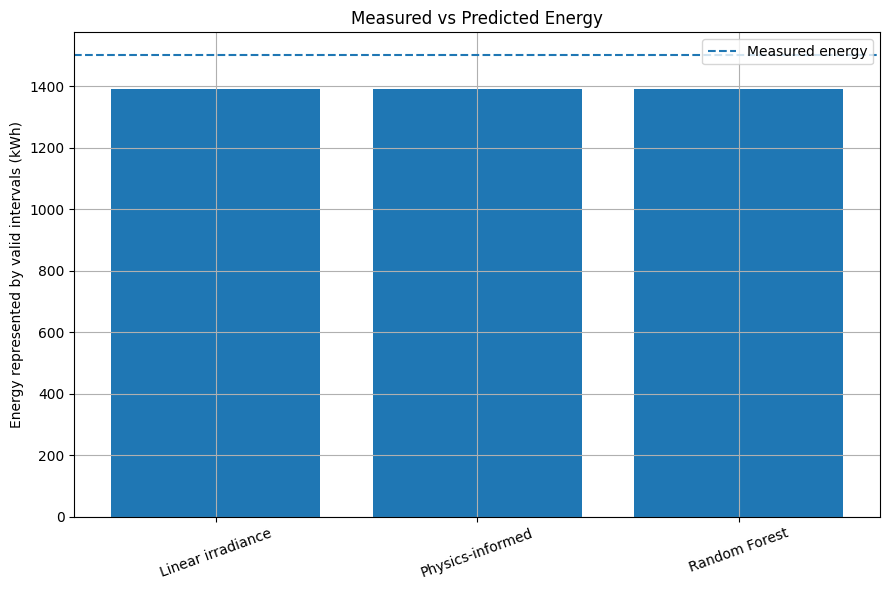

In [38]:
# Energy comparison across valid measurement intervals

energy_plot = energy_results[
    energy_results["Model"] != "Measured"
].copy()

plt.figure(figsize=(9, 6))

plt.bar(
    energy_plot["Model"],
    energy_plot["Energy_kWh"]
)

# Add measured reference line
plt.axhline(
    total_measured,
    linestyle="--",
    linewidth=1.5,
    label="Measured energy"
)

plt.ylabel("Energy represented by valid intervals (kWh)")
plt.title("Measured vs Predicted Energy")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
plt.savefig(
    "energy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

print("Figure saved.")

Figure saved.


<Figure size 1000x600 with 0 Axes>

### 10.10 Final Data and Model Check

A final consistency check is performed to confirm the number of observations used for modelling, the training and test-set sizes, missing values, training-set outlier screening, model evaluation metrics, and energy-analysis coverage.

This provides a final verification that the main stages of the analysis have completed as expected.

In [40]:
print("FINAL DATA / MODEL CHECK")
print("=" * 40)

print("\nDataset:")
print("Total modelling observations:", len(model_data))
print("Training observations:", len(train_data))
print("Training observations after screening:", len(train_clean))
print("Test observations:", len(test_data))

print("\nMissing values in test set:")
print(test_data[
    [
        "poa_irradiance_W_m2",
        "module_temp_C",
        "ambient_temp_C",
        "ac_power_kW"
    ]
].isna().sum())

print("\nTraining outlier screening:")
print("Flagged:", train_data["outlier"].sum())
print("Threshold (kW):", threshold)

print("\nTest-set evaluation:")
print("Baseline MAE:", baseline_mae)
print("Physics MAE:", physics_mae)
print("RF MAE:", rf_mae)

print("\nEnergy analysis:")
print("Measured energy across valid intervals:", total_measured, "kWh")
print("Valid interval coverage:",
      energy_data["valid_interval"].sum(), "intervals")

print("\nAll checks completed.")

FINAL DATA / MODEL CHECK

Dataset:
Total modelling observations: 374
Training observations: 263
Training observations after screening: 245
Test observations: 111

Missing values in test set:
poa_irradiance_W_m2    0
module_temp_C          0
ambient_temp_C         0
ac_power_kW            0
dtype: int64

Training outlier screening:
Flagged: 18
Threshold (kW): 11.830426410786359

Test-set evaluation:
Baseline MAE: 6.832027371601242
Physics MAE: 6.6133396962250535
RF MAE: 6.8270952527303495

Energy analysis:
Measured energy across valid intervals: 1500.484169 kWh
Valid interval coverage: 100 intervals

All checks completed.
